# The orbital magnetization: the half of a moment that circulates

A magnet's moment has two parts. The spin part is an integral over the cell and every code
prints it. The orbital part is not an integral of anything local: the current a Bloch state
carries goes *through* the crystal, so $\int \mathbf r \times \mathbf j$ depends on where
you cut the cell and is not a property of the material at all. That is the same difficulty
the electric polarization has, and it has the same resolution. What is well defined is a
quantity in k-space,

$$ \mathbf M \;=\; \frac{e}{2\hbar c}\,\mathrm{Im} \sum_n \int \frac{d\mathbf k}{(2\pi)^3}\,
   \big\langle \partial_{\mathbf k} u_n \big| \times
   \big( H_{\mathbf k} + \varepsilon_{n\mathbf k} - 2\mu \big)
   \big| \partial_{\mathbf k} u_n \big\rangle , $$

a **local** circulation going round inside each cell plus an **itinerant** one drifting
along the boundary. Neither is separately measurable and their sum is.

It needs two things at once, and either alone gives exactly zero: time reversal has to be
broken, so the system must be magnetic, and spin and orbital motion have to be coupled, so
it needs spin-orbit coupling.

The system here is the smallest one that has both: **a single iodine atom in a box**.
Neutral iodine is $5s^2 5p^5$, one hole in the p shell, and Hund's rules give $S = 1/2$,
$L = 1$, and, the shell being more than half full, $J = 3/2$ with the orbital angular
momentum locked parallel to the spin.

| | this code | Quantum ESPRESSO |
|---|---|---|
| local circulation $M_{LC}$ | $-0.598639$ | $-0.598637$ |
| itinerant circulation $M_{IC}$ | $-0.575800$ | $-0.575799$ |
| **total, $\mu_B$ per cell** | **$-1.174438$** | **$-1.174436$** |
| spin moment | $1.0000$ | $1.00$ |
| $\langle L_z\rangle$ on the atom itself | $0.99977\,\hbar$ | not computed |

In [1]:
from pathlib import Path

from defumat import Calculator

PSEUDO, CASES = Path("../tests/data/pseudo"), Path("../tests/data/qe")

iodine = Calculator.from_file(CASES / "i-atom-soc.in", PSEUDO, announce=False)
orbm = iodine.get_orbital_magnetization(divisions=(3, 3, 3))

print(f"M_LC   = {orbm.lc[2]:.6f} mu_B/cell")
print(f"M_IC   = {orbm.ic[2]:.6f} mu_B/cell")
print(f"total  = {orbm.total[2]:.6f} mu_B/cell")

M_LC   = -0.598639 mu_B/cell
M_IC   = -0.575800 mu_B/cell
total  = -1.174438 mu_B/cell


## What the number says

About one Bohr magneton, which is what Hund's rules ask for: a p shell with one hole
carries $L = 1$, so an orbital moment of order $\mu_B$ is the answer to expect, and nothing
in the calculation was told that. The sign is the electron's charge, and the magnitude is
the interesting part, because it is not $1.000$ but $1.174$.

The two terms are the split Quantum ESPRESSO prints, and only their sum is a physical
quantity: one carries the Hamiltonian between the two derivatives and the other the band
energies. They come out nearly equal here, which is a property of this particular set of
levels rather than a statement about two separate currents.

The manifold has to be gapped for any of this to be defined, and this one is, by 0.16 eV.
That is what the fixed occupations in the input file are for: a smearing wide enough to
converge an atom comfortably would put a fifth of an electron in the eighth band, and then
there is no manifold to speak of.

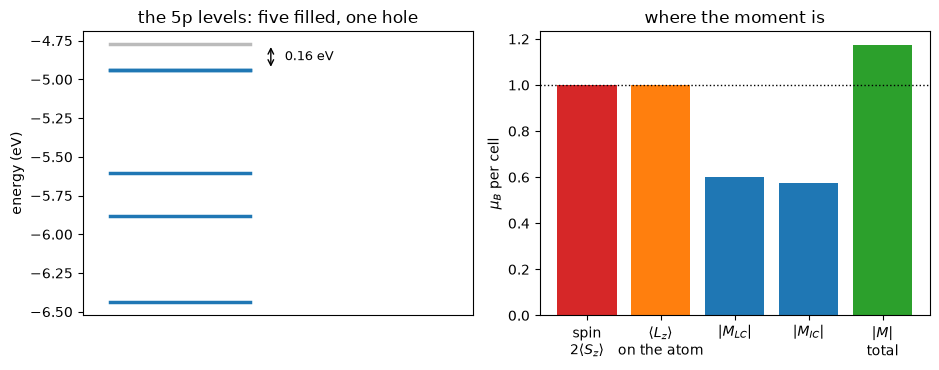

In [2]:
import matplotlib.pyplot as plt
import numpy as np

from defumat.units import RY_TO_EV

levels = np.asarray(iodine.get_scf().eigenvalues).reshape(-1)[:8] * RY_TO_EV
momenta = iodine.get_angular_momenta()

fig, (left, right) = plt.subplots(1, 2, figsize=(9.5, 3.8))
for band, energy in enumerate(levels):
    if energy < -10:                      # the 5s pair, ten eV further down
        continue
    left.plot([0, 1], [energy, energy], lw=2.5,
              color="#1f77b4" if band < 7 else "#bbbbbb")
left.annotate("", (1.15, levels[6]), (1.15, levels[7]),
              arrowprops=dict(arrowstyle="<->"))
left.text(1.25, 0.5 * (levels[6] + levels[7]), "0.16 eV", va="center", fontsize=9)
left.set(xticks=[], ylabel="energy (eV)", xlim=(-0.2, 2.6),
         title="the 5p levels: five filled, one hole")

labels = ["spin\n$2\\langle S_z\\rangle$", "$\\langle L_z\\rangle$\non the atom",
          "$|M_{LC}|$", "$|M_{IC}|$", "$|M|$\ntotal"]
values = [2 * momenta.total_spin[2], momenta.total_orbital[2],
          abs(orbm.lc[2]), abs(orbm.ic[2]), abs(orbm.total[2])]
right.bar(labels, values, color=["#d62728", "#ff7f0e", "#1f77b4", "#1f77b4", "#2ca02c"])
right.axhline(1.0, color="k", ls=":", lw=1)
right.set(ylabel="$\\mu_B$ per cell", title="where the moment is")
fig.tight_layout()

## Against Quantum ESPRESSO

`pw.x` computes this too, and prints the same two terms. The comparison below is on the
same $3\times3\times3$ grid and the same converged density, so what is left between the two
numbers is how far apart two separately converged self-consistent fields are, which on this
cell is a couple of parts in a million.

In [3]:
import re

reference = re.findall(r"M_(LC|IC) =.*?\n *M_\1 =((?: *\S+){3}) *\(Bohr",
                       (CASES / "reference.out.i-atom-soc-orbm").read_text())
qe = {name: float(values.split()[2]) for name, values in reference}

print("            here          pw.x        difference")
for name, ours in (("LC", orbm.lc[2]), ("IC", orbm.ic[2])):
    print(f"M_{name}   {ours:12.7f}  {qe[name]:12.7f}   {abs(ours - qe[name]):.1e}")
total = qe["LC"] + qe["IC"]
print(f"total  {orbm.total[2]:12.7f}  {total:12.7f}   {abs(orbm.total[2] - total):.1e}")

            here          pw.x        difference
M_LC     -0.5986388    -0.5986370   1.9e-06
M_IC     -0.5757995    -0.5757987   7.7e-07
total    -1.1744384    -1.1744357   2.7e-06


## The part that is not on the atom

The bar chart holds one comparison worth pausing on. Projecting the wavefunctions onto the
atom's own orbitals and taking $\langle L_z \rangle$ gives $0.99977\,\hbar$, which is
Hund's rules to four decimals. The orbital magnetization of the same run is $1.174\,\mu_B$.

The difference is not an error in either, and it is two things rather than one. A
projection can only see what circulates *inside* the atom's own orbitals, where the k-space
expression counts the current everywhere in the cell. And the two use different velocities:
$\langle L \rangle$ is $\mathbf r \times \mathbf p$, while the modern theory contracts the
Hamiltonian, whose commutator with $\mathbf r$ carries the nonlocal part of the
pseudopotential as well.

For an atom in a box the two are close, because most of the circulation really is on the
atom. In a crystal, where the bonds carry current of their own, the gap is much larger, and
it is the whole reason this quantity is computed in k-space rather than as a sum over
sites.

## What it refuses

- **A run without spin-orbit coupling**, where the orbital moment is quenched identically:
  spin and orbital motion decouple and a global spin rotation costs nothing. Switching the
  coupling off inside the same relativistic dataset takes the answer to $10^{-9}$.
- **A collinear run** (`nspin = 2`), which is the same statement: each spin channel is
  separately time-reversal symmetric.
- **A metal**, or any set of bands not separated from the ones above it. The construction
  is a derivative of an occupied manifold and there is no manifold without a gap; a run
  whose gap is too small to trust is refused by name rather than answered.
- **Ultrasoft and PAW datasets.** Quantum ESPRESSO refuses the same combination.
- **A spin spiral**, and a mesh with only two divisions along a direction that carries a
  derivative, where a point's two neighbours are the same k-point and a central difference
  is an alias rather than a derivative. One division is allowed, and sets that direction's
  derivative to zero, which is what a slab means.

---

The comparison against `pw.x`, the null with the coupling switched off and the sign and
size of the moment are in `tests/regression/test_orbital_magnetization.py`; the gauge
invariance of the construction, the Chern number that comes out of the same sums, and the
mesh rules are checked on tight-binding models in
`tests/unit/test_orbital_magnetization.py`.